In [3]:
## DELTAKIT STIM ##
import deltakit_stim
# Deltakit circuit clashes with deltakit_stim unless do these injections
injections = ['stim._detect_machine_architecture', 'stim._stim_polyfill', 'stim']
import sys
for namespace in injections:
    sys.modules[namespace] = sys.modules[f"deltakit_{namespace}"]


## BB_IONS ##
import os
sys.path.append(os.path.abspath("../src"))
from bb_ions import *

<class 'deltakit_stim._stim_polyfill.Circuit'>


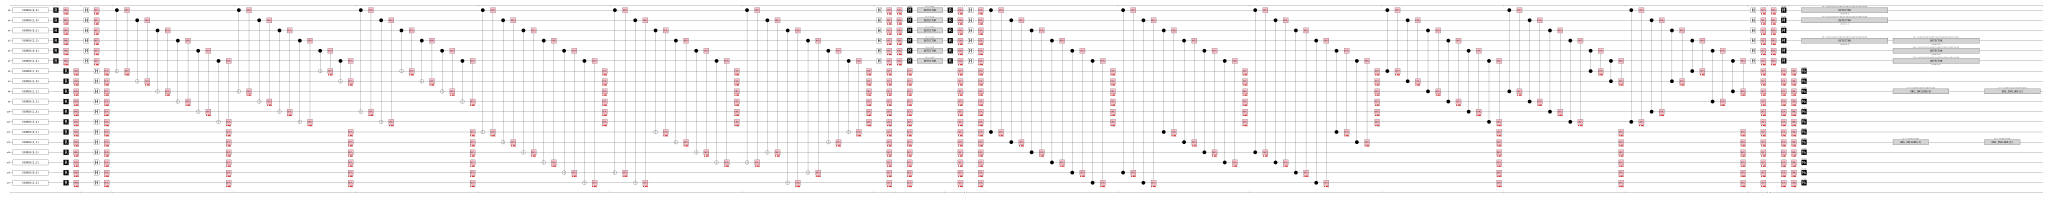

In [8]:
# Trying this on one of my stim circuits:

code = bb6_12_4_2()
p = 0.001
memory_basis = 'X'

circuit = make_BB_circuit(  # see src/bb_ions/circfuncs for explanation of make_BB_circuit inputs
    code,
    p,  
    errors = uniform_errors(p),
    idle_during = uniform_idling(p),
    num_syndrome_extraction_cycles = 1,  
    memory_basis = memory_basis,
    sequential_gates = False,
    exclude_opposite_basis_detectors = False,
    reuse_check_qubits = True,
    swap_LRC = False,
    only_CZs = False
)

print(type(stim_circuit))
svg = stim_circuit.diagram('timeline-svg')
display(svg)
with open(f"../scrap.svg", "w", encoding="utf-8") as f: f.write(str(svg))

In [9]:
sampler = circuit.compile_detector_sampler()
detection_events = sampler.sample(shots=10)